In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop(columns=['customerID'])

y_raw = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['Churn'])

categorical_cols = X.select_dtypes(include='object').columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
y_onehot = to_categorical(y_raw, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_onehot, test_size=0.2, random_state=42, stratify=y_raw
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_features = X_train_scaled.shape[1]
num_classes = 2

print("Train shape:", X_train_scaled.shape)

Train shape: (5634, 30)


In [3]:
basic_model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(num_features,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

basic_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

basic_history = basic_model.fit(
    X_train_scaled, y_train,
    epochs=50, batch_size=32,
    validation_split=0.2, verbose=0
)

print("Basic model final val_accuracy:", basic_history.history['val_accuracy'][-1])

c:\Users\COMPUTER ARENA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Basic model final val_accuracy: 0.7426796555519104


In [4]:
improved_model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(num_features,)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(32, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(num_classes, activation='softmax')
])

improved_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,514 (17.63 KB)

 Trainable params: 4,322 (16.88 KB)

 Non-trainable params: 192 (768.00 B)

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '../outputs/best_improved_model.keras',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

callbacks_list = [early_stop, checkpoint, reduce_lr]

In [8]:
improved_history = improved_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8045 - loss: 0.4114 - val_accuracy: 0.7986 - val_loss: 0.4323 - learning_rate: 1.2500e-04
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8054 - loss: 0.4144 - val_accuracy: 0.7995 - val_loss: 0.4325 - learning_rate: 1.2500e-04
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8092 - loss: 0.4104 - val_accuracy: 0.7986 - val_loss: 0.4326 - learning_rate: 1.2500e-04
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8021 - loss: 0.4122 - val_accuracy: 0.7986 - val_loss: 0.4326 - learning_rate: 6.2500e-05
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8072 - loss: 0.4087 - val_accuracy: 0.7995 - val_loss: 0.4326 - learning_rate: 6.2500e-05


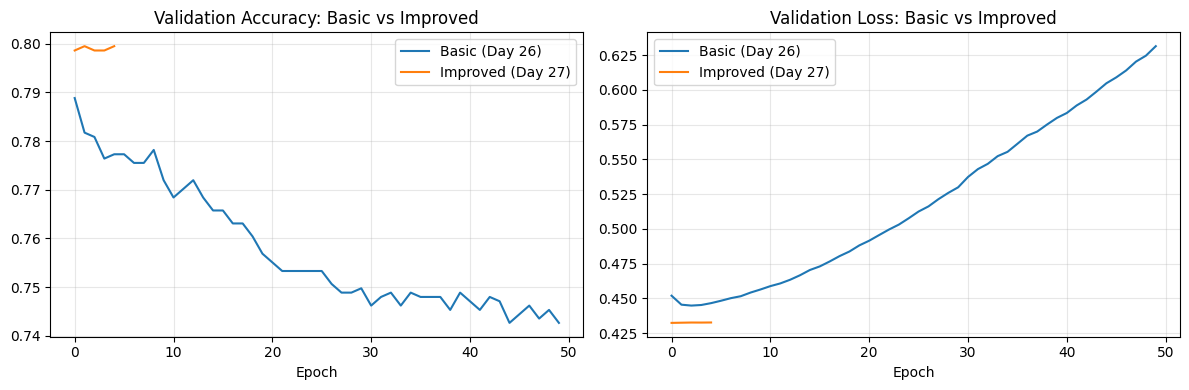

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(basic_history.history['val_accuracy'], label='Basic (Day 26)')
axes[0].plot(improved_history.history['val_accuracy'], label='Improved (Day 27)')
axes[0].set_title('Validation Accuracy: Basic vs Improved')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(basic_history.history['val_loss'], label='Basic (Day 26)')
axes[1].plot(improved_history.history['val_loss'], label='Improved (Day 27)')
axes[1].set_title('Validation Loss: Basic vs Improved')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/basic_vs_improved_curves.png', dpi=120)
plt.show()

In [10]:
basic_test_loss, basic_test_acc = basic_model.evaluate(X_test_scaled, y_test, verbose=0)
improved_test_loss, improved_test_acc = improved_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Basic model    -> Test Accuracy: {basic_test_acc:.4f}, Test Loss: {basic_test_loss:.4f}")
print(f"Improved model -> Test Accuracy: {improved_test_acc:.4f}, Test Loss: {improved_test_loss:.4f}")

Basic model    -> Test Accuracy: 0.7551, Test Loss: 0.5918
Improved model -> Test Accuracy: 0.7913, Test Loss: 0.4263


In [11]:
def build_dropout_model(dropout_rate, num_features=num_features, num_classes=num_classes):
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(num_features,)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(32, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

dropout_rates = [0.2, 0.4, 0.6]
dropout_histories = {}

for rate in dropout_rates:
    print(f"Training with dropout rate = {rate}")
    m = build_dropout_model(rate)
    h = m.fit(
        X_train_scaled, y_train,
        epochs=30, batch_size=32,
        validation_split=0.2, verbose=0
    )
    dropout_histories[rate] = h

Training with dropout rate = 0.2
Training with dropout rate = 0.4
Training with dropout rate = 0.6


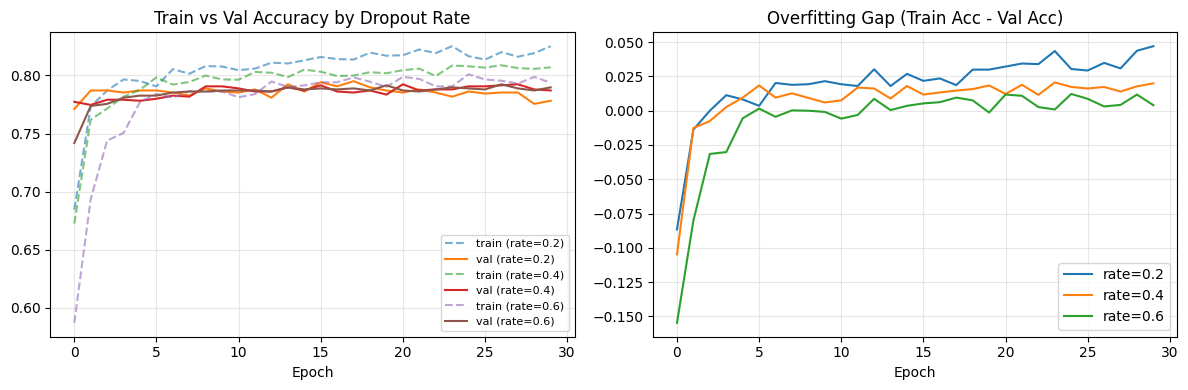

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for rate, h in dropout_histories.items():
    axes[0].plot(h.history['accuracy'], label=f'train (rate={rate})', linestyle='--', alpha=0.6)
    axes[0].plot(h.history['val_accuracy'], label=f'val (rate={rate})')

axes[0].set_title('Train vs Val Accuracy by Dropout Rate')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for rate, h in dropout_histories.items():
    gap = np.array(h.history['accuracy']) - np.array(h.history['val_accuracy'])
    axes[1].plot(gap, label=f'rate={rate}')

axes[1].set_title('Overfitting Gap (Train Acc - Val Acc)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/dropout_rate_comparison.png', dpi=120)
plt.show()

In [13]:
# Model 1: ExponentialDecay schedule
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=100,
    decay_rate=0.9
)

model_exp_decay = build_dropout_model(0.4)
model_exp_decay.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_exp_decay = model_exp_decay.fit(
    X_train_scaled, y_train,
    epochs=30, batch_size=32,
    validation_split=0.2, verbose=0
)

# Model 2: ReduceLROnPlateau
model_reduce_lr = build_dropout_model(0.4)
model_reduce_lr.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_reduce_lr = model_reduce_lr.fit(
    X_train_scaled, y_train,
    epochs=30, batch_size=32,
    validation_split=0.2,
    callbacks=[ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)],
    verbose=0
)

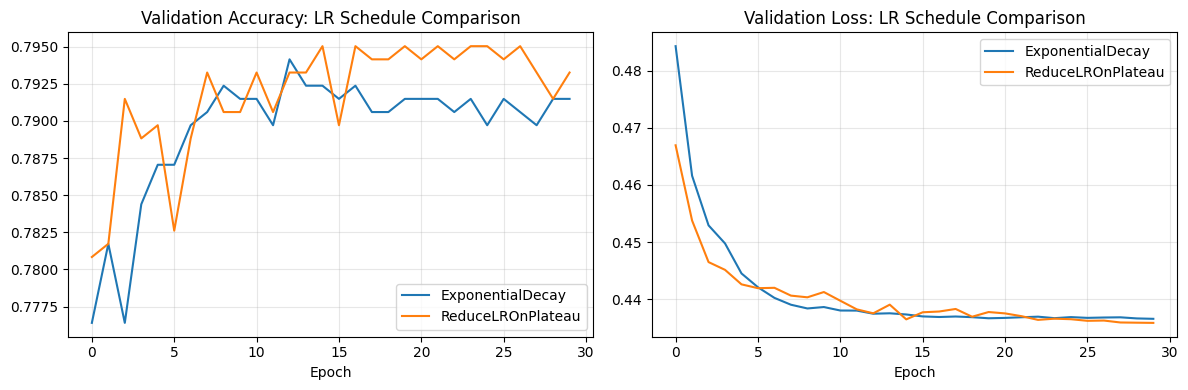

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_exp_decay.history['val_accuracy'], label='ExponentialDecay')
axes[0].plot(history_reduce_lr.history['val_accuracy'], label='ReduceLROnPlateau')
axes[0].set_title('Validation Accuracy: LR Schedule Comparison')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_exp_decay.history['val_loss'], label='ExponentialDecay')
axes[1].plot(history_reduce_lr.history['val_loss'], label='ReduceLROnPlateau')
axes[1].set_title('Validation Loss: LR Schedule Comparison')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/lr_schedule_comparison.png', dpi=120)
plt.show()

## Techniques Summary

| Technique          | What It Does                                              | When to Use It                                  | Where to Place It                            |
|---------------------|------------------------------------------------------------|--------------------------------------------------|-----------------------------------------------|
| Dropout             | Randomly turns off a fraction of neurons during training   | When model overfits (train acc >> val acc)       | After Dense/hidden layers, never on output    |
| Batch Normalization  | Normalizes layer activations to zero mean/unit variance     | To speed up and stabilize training                | After Dense/Conv2D, before activation          |
| EarlyStopping        | Stops training when val_loss stops improving                | Always — prevents wasted epochs and overfitting   | Passed into `model.fit(callbacks=[...])`       |
| ModelCheckpoint      | Saves the best model weights during training                | Always — ensures you keep the best version        | Passed into `model.fit(callbacks=[...])`       |
| ReduceLROnPlateau    | Lowers learning rate when progress stalls                   | When training plateaus                            | Passed into `model.fit(callbacks=[...])`       |